# Notebook 02 — Análisis Exploratorio de Datos (EDA)

## Objetivo

Analizar las características temporales de la serie de huella de carbono operacional global para España con resolución de 15 minutos.

Se estudian:

- Evolución temporal
- Estacionalidad diaria y semanal
- Distribuciones
- Autocorrelación


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")
# inline matplotlib in jupyter notebook
%matplotlib inline


In [2]:
df = pd.read_parquet("data_processed/es_carbon_footprint_operational_global_15min_2022_2025.parquet")

df.head()


,y
timestamp,
2022-01-01 00:00:00+00:00,120.79
2022-01-01 00:15:00+00:00,120.79
2022-01-01 00:30:00+00:00,120.79
2022-01-01 00:45:00+00:00,120.80
2022-01-01 01:00:00+00:00,120.04


In [3]:
# Ver si hay valores nulos
print("Valores nulos por columna:")
df.isnull().sum()


Valores nulos por columna:


y    0
dtype: int64

01_data_loading.ipynb
02_eda.ipynb
03_baseline_arima.ipynb
04_sarima.ipynb
05_sarimax.ipynb
06_ml_models.ipynb
07_lstm.ipynb
08_country_comparison.ipynb


In [4]:
from pathlib import Path

FIG_DIR = Path("..") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)



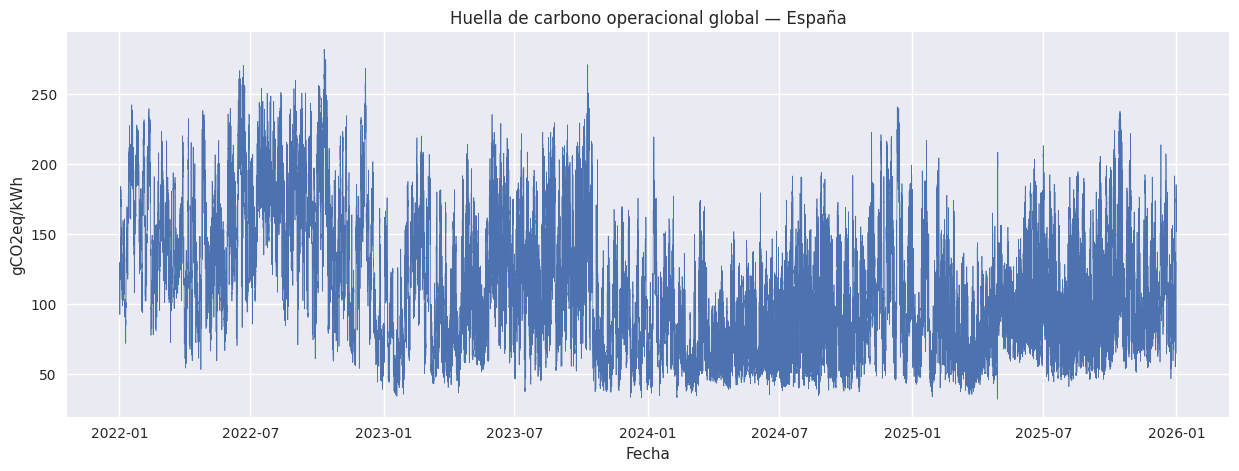

In [5]:

plt.figure(figsize=(15,5))
plt.plot(df.index, df["y"], linewidth=0.5)
plt.title("Huella de carbono operacional global — España")
plt.xlabel("Fecha")
plt.ylabel("gCO2eq/kWh")
plt.savefig(FIG_DIR / "serie_completa.png", dpi=300, bbox_inches="tight")
plt.show()


### Evolución temporal de la huella de carbono

La figura muestra la evolución temporal de la huella de carbono operacional del consumo eléctrico en España durante el periodo de estudio.

Se observan variaciones significativas a lo largo del tiempo, con cambios en el nivel medio y en la variabilidad de la serie entre años. Estas diferencias pueden estar asociadas a modificaciones en el mix de generación eléctrica, la disponibilidad de energías renovables y la evolución de la demanda energética.

Asimismo, se aprecia una elevada variabilidad intra-diaria, lo que sugiere la presencia de patrones estacionales de corta escala temporal.


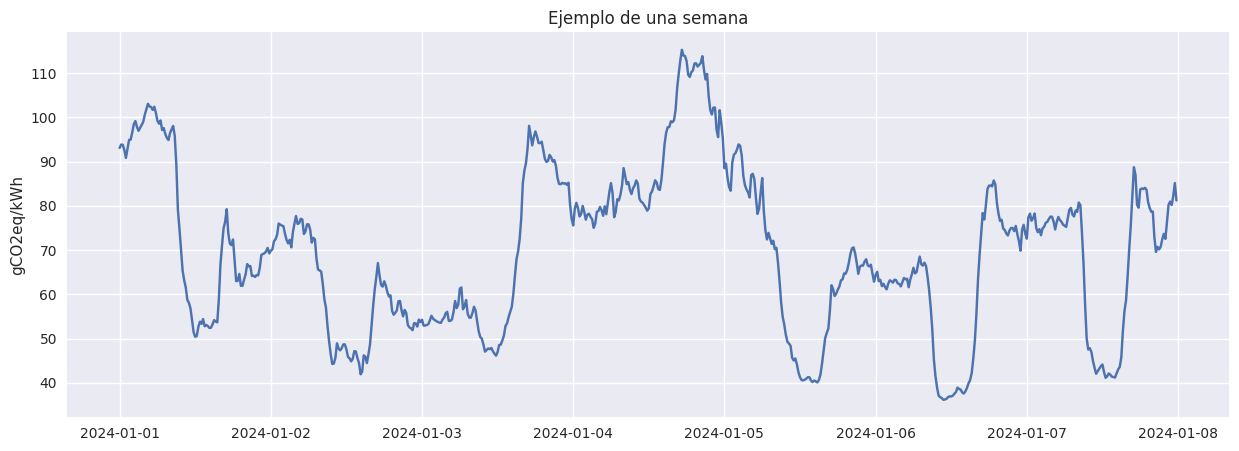

In [6]:
week = df.loc["2024-01-01":"2024-01-07"]

plt.figure(figsize=(15,5))
plt.plot(week.index, week["y"])
plt.title("Ejemplo de una semana")
# Unidades del eje y 
plt.ylabel("gCO2eq/kWh")
plt.savefig(FIG_DIR / "ejemplo_semana.png", dpi=300, bbox_inches="tight")
plt.show()


### Dinámica temporal a escala semanal

Se muestra un ejemplo de una semana representativa con el objetivo de analizar la dinámica de la serie a una escala temporal más reducida.

Se identifican ciclos diarios claramente definidos, con patrones repetitivos que indican la presencia de estacionalidad asociada al comportamiento de la demanda eléctrica y a la disponibilidad de generación renovable.


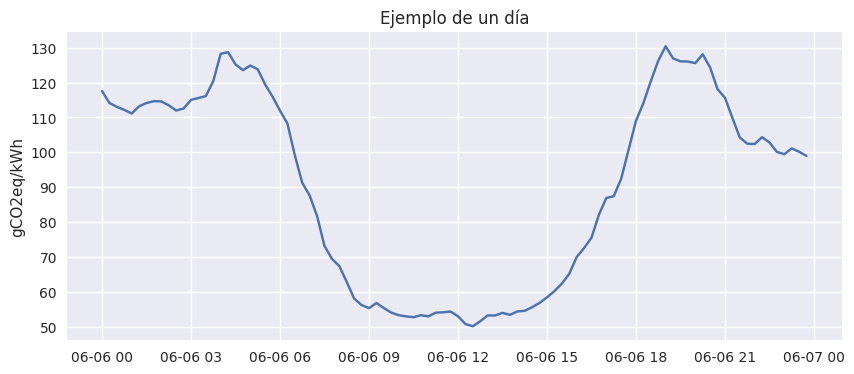

In [7]:
day = df.loc["2024-06-06"]

plt.figure(figsize=(10,4))
plt.plot(day.index, day["y"])
plt.ylabel("gCO2eq/kWh")
plt.title("Ejemplo de un día")
plt.savefig(FIG_DIR / "ejemplo_dia.png", dpi=300, bbox_inches="tight")
plt.show()


### Variación intra-diaria

La figura representa la evolución de la huella de carbono durante un día concreto.

Se observa una disminución de los valores durante las horas centrales del día y un incremento durante la tarde y la noche. Este comportamiento es consistente con la mayor penetración de generación solar durante el día y el aumento de generación térmica (principalmente con ciclos comnbinados de gas natural) en horas sin radiación solar.


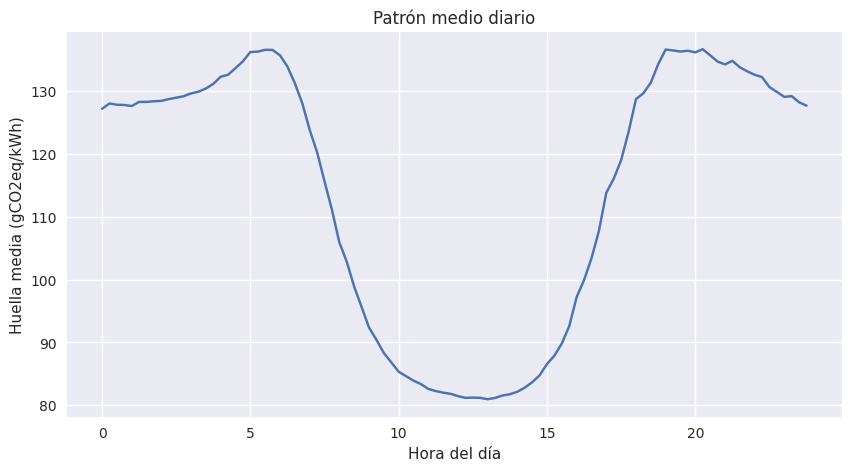

In [8]:
df["hour"] = df.index.hour + df.index.minute / 60

daily_pattern = df.groupby("hour")["y"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_pattern.index, daily_pattern.values)
plt.title("Patrón medio diario")
plt.xlabel("Hora del día")
plt.ylabel("Huella media (gCO2eq/kWh)")
plt.savefig(FIG_DIR / "patron_diario.png", dpi=300, bbox_inches="tight")
plt.show()


### Patrón medio diario

El patrón medio diario lo obtenemos promediando la serie temporal por hora del día.

Observamos una estructura clara en forma de valle durante las horas centrales y picos en periodos nocturnos y de tarde, lo que confirma la existencia de una fuerte estacionalidad diaria en la huella de carbono del sistema eléctrico.


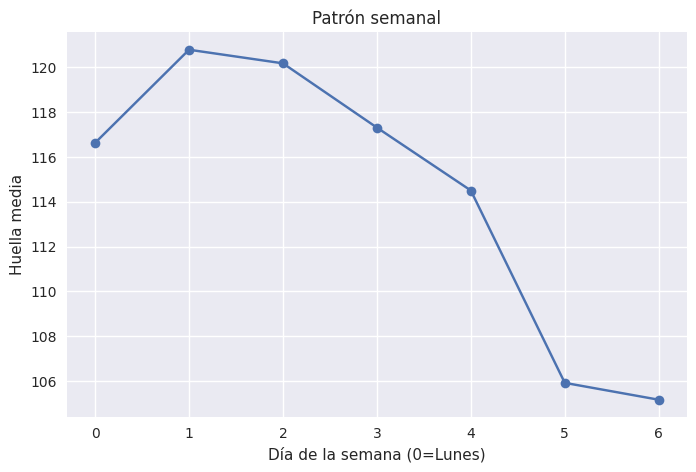

In [9]:
df["weekday"] = df.index.dayofweek

weekly_pattern = df.groupby("weekday")["y"].mean()

plt.figure(figsize=(8,5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker="o")
plt.title("Patrón semanal")
plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Huella media")
plt.savefig(FIG_DIR / "patron_semanal.png", dpi=300, bbox_inches="tight")
plt.show()


### Patrón semanal

La figura muestra la huella media en función del día de la semana.

Observamos una ligera reducción durante el fin de semana, lo que puede asociarse a menores niveles de actividad económica e industrial, y por ello de demanda eléctrica respecto a los días laborables.


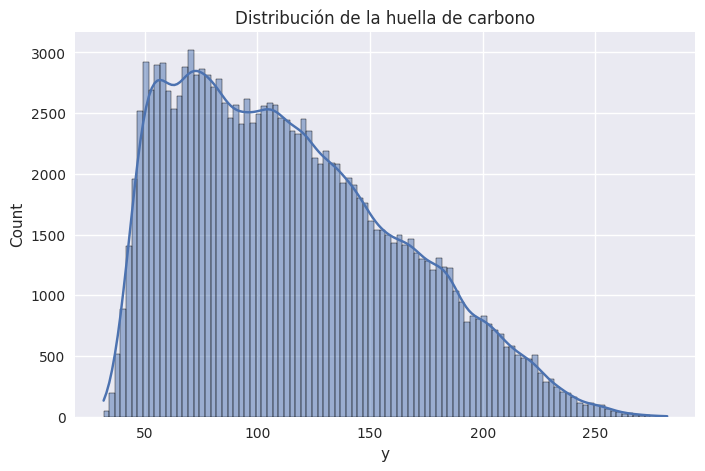

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["y"], bins=100, kde=True)
plt.title("Distribución de la huella de carbono")
plt.savefig(FIG_DIR / "distribucion_huella.png", dpi=300, bbox_inches="tight")
plt.show()


### Distribución de la huella de carbono

La distribución de valores muestra una asimetría positiva, con mayor concentración en valores medios y una cola hacia valores altos.

Esta distribución refleja la existencia de episodios puntuales de elevada huella de carbono asociados a situaciones específicas del sistema eléctrico.


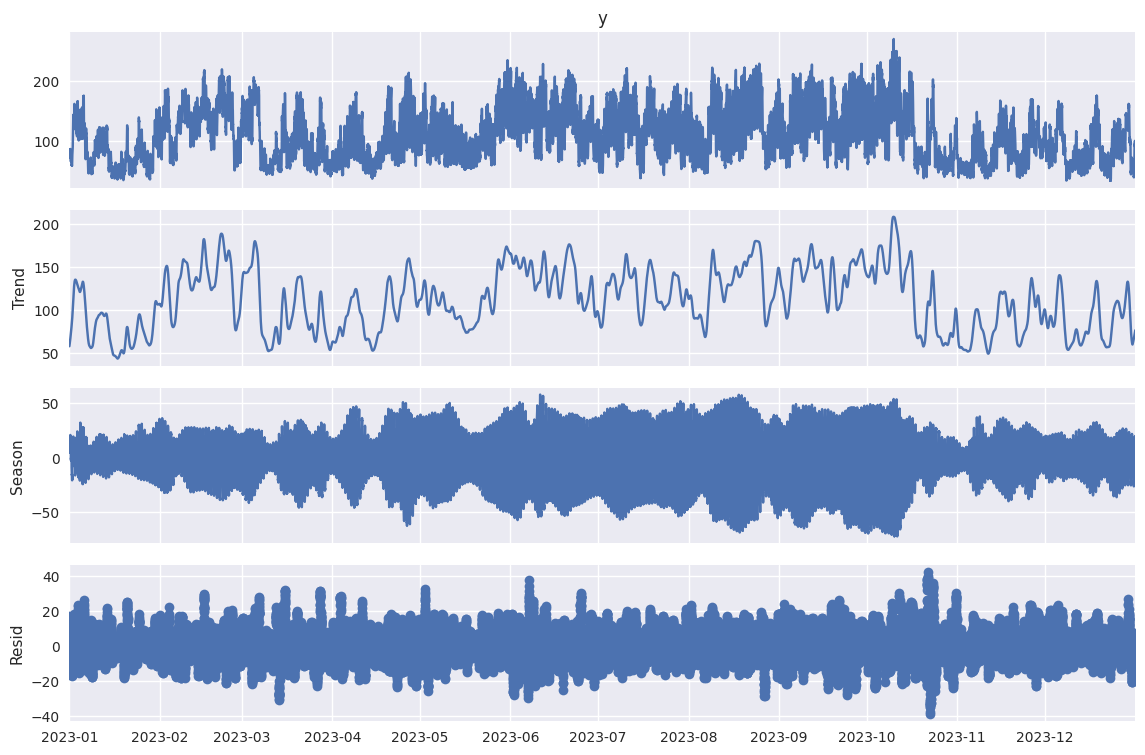

In [11]:
from statsmodels.tsa.seasonal import STL

subset = df.loc["2023"]

stl = STL(subset["y"], period=96)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)

plt.savefig(FIG_DIR / "stl_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()



### Descomposición de la serie temporal

La descomposición STL permite separar la serie en sus componentes de tendencia, estacionalidad y residuo.

La componente estacional muestra patrones diarios claramente definidos, mientras que la tendencia refleja variaciones de mayor escala temporal. Los residuos presentan una distribución aproximadamente centrada en cero, lo que indica que la descomposición captura adecuadamente la estructura principal de la serie.

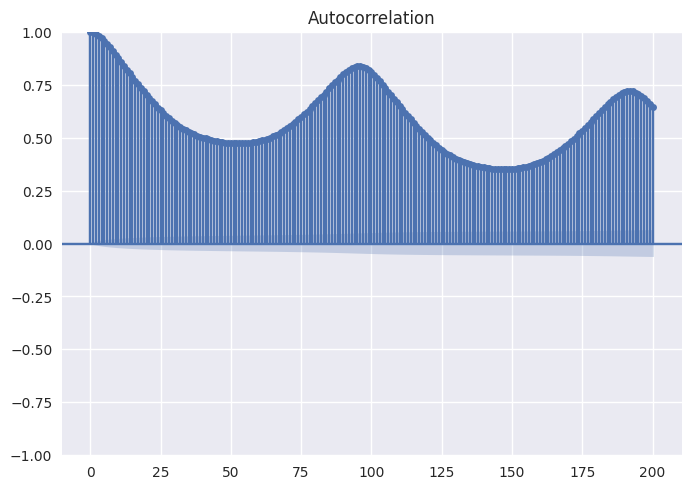

In [12]:
plot_acf(df['y'], lags=200)
plt.savefig(FIG_DIR / "acf.png", dpi=300, bbox_inches="tight")
plt.show()



### Autocorrelación

La función de autocorrelación muestra valores elevados en retardos pequeños y picos periódicos que corresponden a múltiplos del ciclo diario (96 intervalos de 15 minutos).

Esto confirma la existencia de dependencia temporal y estacionalidad en la serie.

<Figure size 1000x600 with 0 Axes>

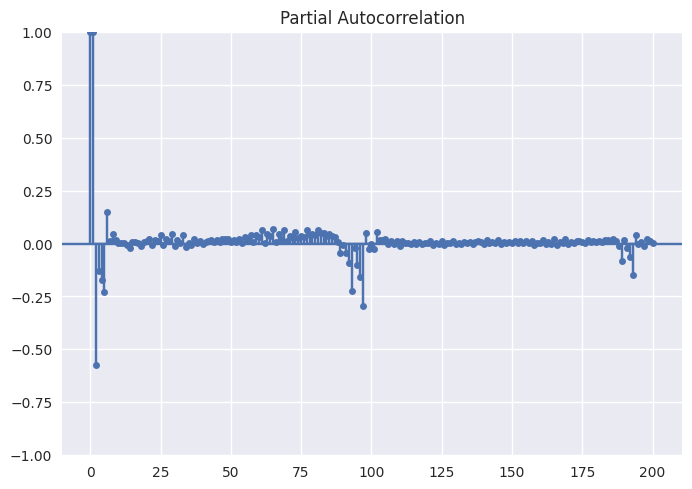

In [13]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 6))
plot_pacf(df['y'], lags=200)

plt.savefig(FIG_DIR / "pacf.png", dpi=300, bbox_inches="tight")
plt.show()


### Autocorrelación parcial

La función de autocorrelación parcial muestra una fuerte dependencia en retardos cercanos y señales en retardos asociados al ciclo diario, lo que sugiere que modelos autorregresivos pueden capturar parte de la dinámica temporal de la serie.

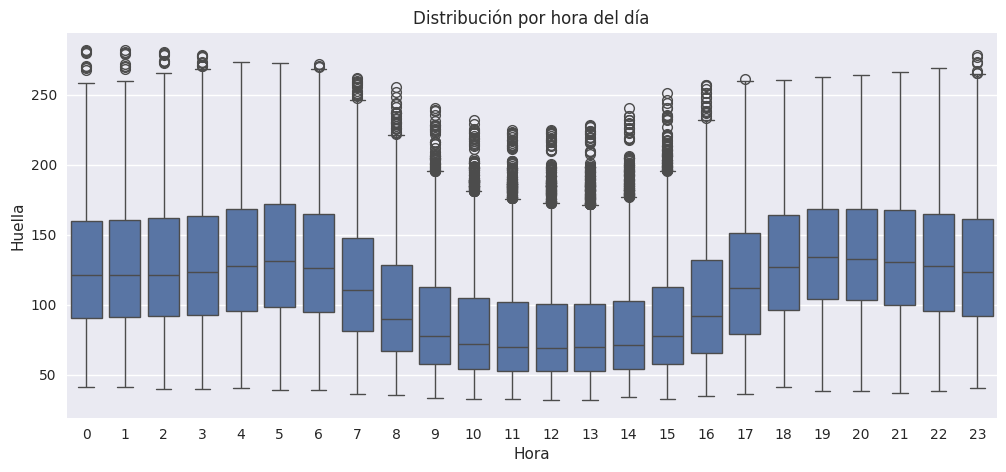

In [14]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df.index.hour, y=df["y"])
plt.title("Distribución por hora del día")
plt.xlabel("Hora")
plt.ylabel("Huella")
plt.savefig(FIG_DIR / "boxplot_hora.png", dpi=300, bbox_inches="tight")
plt.show()


La distribución por hora del día muestra valores mínimos durante las horas centrales y máximos en periodos nocturnos y de tarde, lo que resulta coherente con la disponibilidad de generación renovable y el comportamiento de la demanda eléctrica.

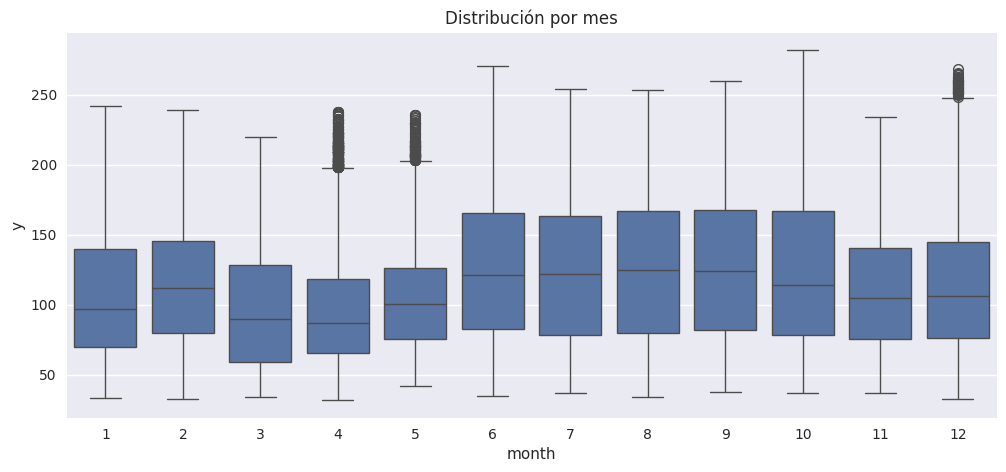

In [15]:
df["month"] = df.index.month

plt.figure(figsize=(12,5))
sns.boxplot(x="month", y="y", data=df)
plt.title("Distribución por mes")
plt.savefig(FIG_DIR / "boxplot_mes.png", dpi=300, bbox_inches="tight")
plt.show()


La variabilidad mensual refleja cambios estacionales en el sistema eléctrico, asociados a diferencias en la demanda y en la disponibilidad de fuentes de generación renovable.

<Axes: title={'center': 'Distribución por año'}, xlabel='year', ylabel='y'>

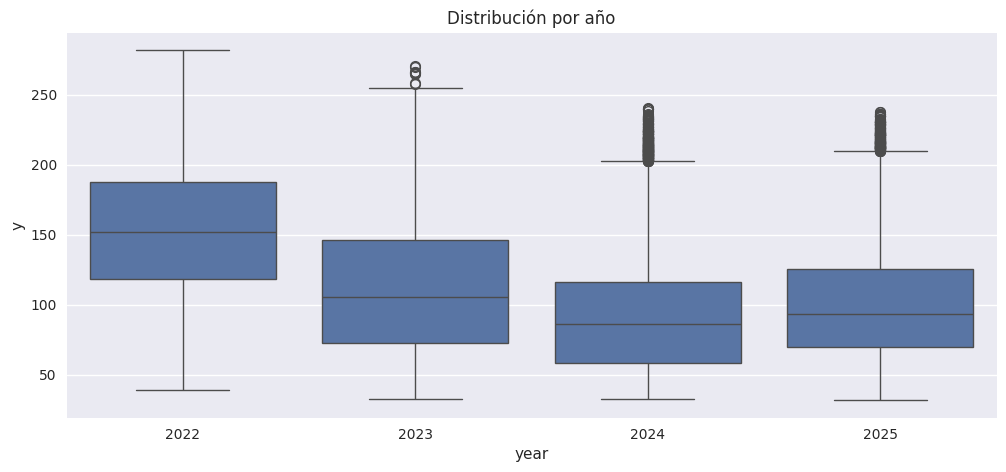

In [16]:
df["year"] = df.index.year
# Titulo
plt.figure(figsize=(12,5))
plt.title("Distribución por año")
sns.boxplot(x="year", y="y", data=df.reset_index())


### Comparación interanual

La comparación por años permite observar cambios en el nivel medio y la variabilidad de la huella de carbono entre periodos.

Se aprecia una reducción progresiva entre 2022 y 2024, seguida de un ligero incremento en 2025. Estas variaciones pueden estar relacionadas con cambios en el mix energético, condiciones meteorológicas y evolución del sistema eléctrico europeo.


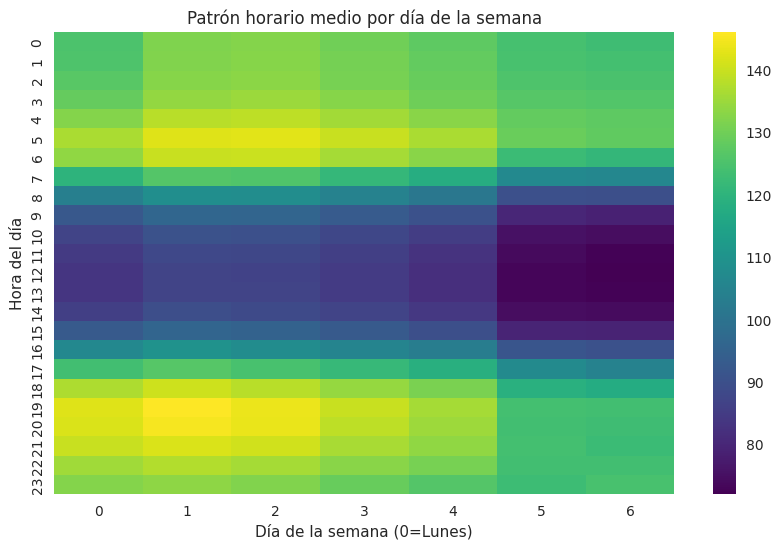

In [17]:
pivot = df.pivot_table(
    values="y",
    index=df.index.hour,
    columns=df.index.dayofweek,
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Hora del día")
plt.title("Patrón horario medio por día de la semana")

plt.savefig(FIG_DIR / "heatmap_hour_weekday.png", dpi=300, bbox_inches="tight")
plt.show()


El mapa de calor permite identificar patrones conjuntos entre la hora del día y el día de la semana. Se observan valores generalmente más elevados en días laborables y reducciones durante el fin de semana, así como una estructura diaria bien definida asociada al comportamiento del sistema eléctrico.

##  Detección de valores atípicos (outliers)

Con el objetivo de identificar posibles anomalías en la serie temporal de la huella de carbono, se realiza un análisis de valores atípicos. 

Los valores extremos pueden corresponder tanto a situaciones reales del sistema eléctrico (por ejemplo, episodios de alta demanda o baja generación renovable) como a posibles errores en los datos. Detectarlos permite evaluar la calidad de la serie y justificar decisiones posteriores en el modelado.

Se emplean dos enfoques:

- Método estadístico basado en el rango intercuartílico (IQR)
- Método basado en desviación respecto a una media móvil temporal


In [18]:
y = df["y"]

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = y[(y < lower) | (y > upper)]

print("Número de outliers (IQR):", len(outliers_iqr))
print("Porcentaje:", round(len(outliers_iqr) / len(y) * 100, 3), "%")
print("Límite inferior:", lower)
print("Límite superior:", upper)


Número de outliers (IQR): 173
Porcentaje: 0.123 %
Límite inferior: -36.705
Límite superior: 258.375


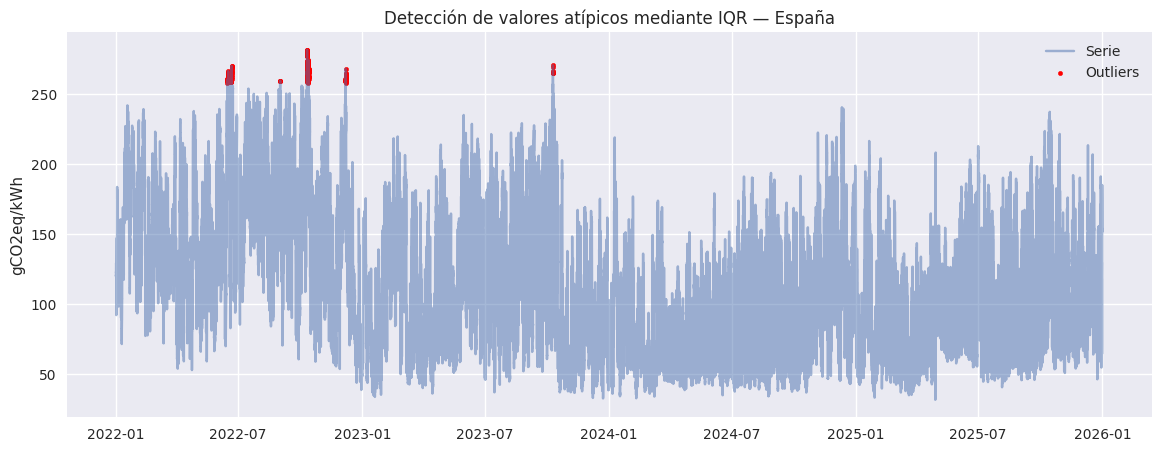

In [19]:
plt.figure(figsize=(14,5))

plt.plot(y.index, y, alpha=0.5, label="Serie")
plt.scatter(outliers_iqr.index, outliers_iqr, color="red", s=10, label="Outliers")

plt.title("Detección de valores atípicos mediante IQR — España")
plt.ylabel("gCO2eq/kWh")
plt.legend()

plt.savefig(FIG_DIR / "outliers_iqr_spain.png", dpi=300, bbox_inches="tight")
plt.show()


El método basado en el rango intercuartílico permite identificar observaciones que se encuentran fuera del rango típico de la serie. 




In [20]:
window = 96  # 24 horas

rolling_mean = y.rolling(window).mean()
rolling_std = y.rolling(window).std()

upper_band = rolling_mean + 3 * rolling_std
lower_band = rolling_mean - 3 * rolling_std

outliers_roll = y[(y > upper_band) | (y < lower_band)]

print("Outliers método rolling:", len(outliers_roll))


Outliers método rolling: 601


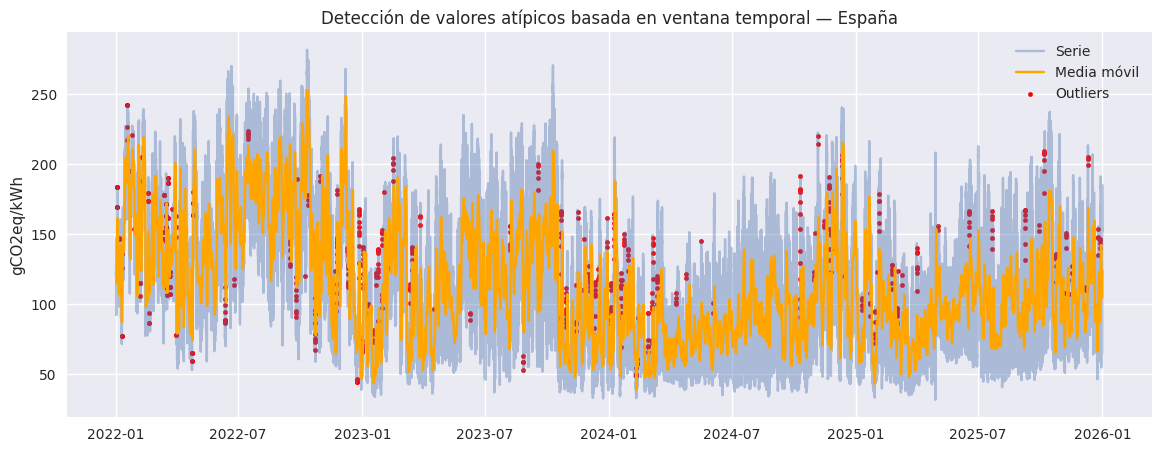

In [21]:
plt.figure(figsize=(14,5))

plt.plot(y.index, y, alpha=0.4, label="Serie")
plt.plot(rolling_mean.index, rolling_mean, color="orange", label="Media móvil")

plt.scatter(outliers_roll.index, outliers_roll, color="red", s=10, label="Outliers")

plt.title("Detección de valores atípicos basada en ventana temporal — España")
plt.ylabel("gCO2eq/kWh")
plt.legend()

plt.savefig(FIG_DIR / "outliers_rolling_spain.png", dpi=300, bbox_inches="tight")
plt.show()


El análisis basado en una ventana temporal permite identificar desviaciones locales respecto al comportamiento esperado de la serie.
Este método detecta un mayor número de observaciones debido a su sensibilidad a variaciones locales en la dinámica de la serie.



El método IQR identificó un porcentaje reducido de observaciones extremas (0.123%), lo que indica una buena calidad general de la serie temporal. Los valores detectados corresponden principalmente a episodios de elevada huella de carbono, plausiblemente asociados a situaciones reales del sistema eléctrico, como una mayor utilización de generación térmica o baja disponibilidad de fuentes renovables.

El análisis basado en ventanas temporales permitió identificar desviaciones locales adicionales, coherentes con la variabilidad inherente del sistema energético.

Dado que los valores extremos detectados reflejan condiciones reales del sistema eléctrico y no errores evidentes en los datos, se decidió mantener todas las observaciones en el análisis para preservar la variabilidad natural de la serie